# EDA — Phân tích Khám phá Dữ liệu NBA
---

## 0. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

# Đọc dữ liệu
df = pd.read_csv("nba_data/nba_full_dataset.csv")
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

print(f"Dataset shape: {df.shape[0]} dòng × {df.shape[1]} cột")
print(f"Số trận đấu: {df['GAME_ID'].nunique()}")
print(f"Số đội: {df['TEAM_ID'].nunique()}")
print(f"Mùa giải: {sorted(df['SEASON'].unique())}")
print(f"Thời gian: {df['GAME_DATE'].min().date()} → {df['GAME_DATE'].max().date()}")

Dataset shape: 12300 dòng × 36 cột
Số trận đấu: 6150
Số đội: 30
Mùa giải: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Thời gian: 2021-10-19 → 2026-04-12


## 1. Tổng quan Dữ liệu

### Tại sao cần bước này?
Bước đầu tiên luôn là **nhìn tổng quan** để nắm được:
- Có bao nhiêu dòng, cột? Kiểu dữ liệu mỗi cột là gì?
- Có **missing values** không? → Nếu không xử lý, nhiều mô hình sẽ crash hoặc học sai.
- Các giá trị thống kê cơ bản (mean, std, min, max) có **hợp lý** không? → Phát hiện lỗi dữ liệu sớm.

Ví dụ: nếu `PTS` (điểm) có max = 500 thì chắc chắn là lỗi, vì kỷ lục NBA chỉ khoảng 186 điểm/trận.

In [2]:
# 1.1 — Kiểu dữ liệu và Missing Values
print("=" * 60)
print("KIỂU DỮ LIỆU VÀ MISSING VALUES")
print("=" * 60)

info_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Missing': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())

print(f"\nTổng missing: {df.isnull().sum().sum()} / {df.shape[0] * df.shape[1]} giá trị")

KIỂU DỮ LIỆU VÀ MISSING VALUES
                              Dtype  Non-Null  Missing  Missing %
SEASON_ID                     int64     12300        0       0.00
TEAM_ID                       int64     12300        0       0.00
TEAM_ABBREVIATION            object     12300        0       0.00
TEAM_NAME                    object     12300        0       0.00
GAME_ID                       int64     12300        0       0.00
GAME_DATE            datetime64[ns]     12300        0       0.00
MATCHUP                      object     12300        0       0.00
WL                           object     12300        0       0.00
MIN                           int64     12300        0       0.00
PTS                           int64     12300        0       0.00
FGM                           int64     12300        0       0.00
FGA                           int64     12300        0       0.00
FG_PCT                      float64     12300        0       0.00
FG3M                          int64     12300

In [3]:
# 1.2 — Thống kê mô tả cho các cột số
print("THỐNG KÊ MÔ TẢ CÁC CỘT SỐ")
print("=" * 60)
df.describe().round(2)

THỐNG KÊ MÔ TẢ CÁC CỘT SỐ


,SEASON_ID,TEAM_ID,GAME_ID,GAME_DATE,MIN,PTS,FGM,FGA,FG_PCT,FG3M,...,TOV,PF,PLUS_MINUS,IS_HOME,WIN,REST_DAYS,IS_B2B,GAMES_PLAYED_SEASON,CURRENT_WIN_PCT,WIN_STREAK
count,12300.00,1.230000e+04,12300.00,12300,12300.00,12300.00,12300.00,12300.00,12300.00,12300.00,...,12300.00,12300.00,12300.00,12300.0,12300.0,12300.00,12300.00,12300.00,12300.00,12300.00
mean,22023.00,1.610613e+09,22300615.50,2024-01-16 02:58:53.268292864,241.49,113.79,41.68,88.73,0.47,12.89,...,13.34,19.36,0.00,0.5,0.5,2.18,0.17,41.50,0.50,-0.08
min,22021.00,1.610613e+09,22100001.00,2021-10-19 00:00:00,236.00,66.00,22.00,64.00,0.28,2.00,...,1.00,4.00,-73.00,0.0,0.0,1.00,0.00,1.00,0.00,-28.00
25%,22022.00,1.610613e+09,22200308.00,2022-11-28 00:00:00,240.00,105.00,38.00,84.00,0.43,10.00,...,11.00,17.00,-10.00,0.0,0.0,2.00,0.00,21.00,0.40,-2.00
50%,22023.00,1.610613e+09,22300615.50,2024-01-19 00:00:00,240.00,113.00,42.00,88.00,0.47,13.00,...,13.00,19.00,1.00,0.0,0.5,2.00,0.00,41.50,0.51,0.00
75%,22024.00,1.610613e+09,22400923.00,2025-03-05 00:00:00,241.00,122.00,45.00,93.00,0.51,15.00,...,16.00,22.00,10.00,1.0,1.0,2.00,0.00,62.00,0.61,2.00
max,22025.00,1.610613e+09,22501230.00,2026-04-12 00:00:00,316.00,176.00,65.00,122.00,0.69,29.00,...,31.00,37.00,73.00,1.0,1.0,9.00,1.00,82.00,1.00,18.00
std,1.41,8.660000e+00,141427.55,NaN,6.52,12.73,5.29,7.15,0.05,3.91,...,3.86,4.17,15.53,0.5,0.5,1.12,0.38,23.67,0.18,3.26


In [4]:
# 1.3 — Xử lý missing value
df['FT_PCT'] = df['FT_PCT'].fillna(0)
print(f"Sau khi xử lý: {df.isnull().sum().sum()} missing values ✓")

Sau khi xử lý: 0 missing values ✓


### Nhận xét Phần 1
- Dữ liệu rất sạch: chỉ 1 giá trị missing ở `FT_PCT` (đội không ném phạt nào trong trận đó)
- Các giá trị thống kê hợp lý (PTS mean ~113, FG_PCT mean ~0.47)

## 2. Phân tích Label (Biến mục tiêu)

Label (`WIN`: 1=thắng, 0=thua) là thứ mô hình cần dự đoán. Ta cần kiểm tra:

- **Cân bằng hay không?** Nếu label bị lệch (ví dụ 90% thắng), mô hình chỉ cần đoán "thắng" mọi lúc cũng đạt 90% accuracy → accuracy không còn là metric tốt. Cần dùng thêm F1-score, AUC.
- **Tỷ lệ thắng sân nhà/khách khác nhau không?** → Nếu có chênh lệch → `IS_HOME` là feature quan trọng.

Trong NBA, mỗi trận có đúng 1 thắng + 1 thua → label luôn cân bằng 50/50. Nhưng vẫn cần xác nhận bằng dữ liệu.

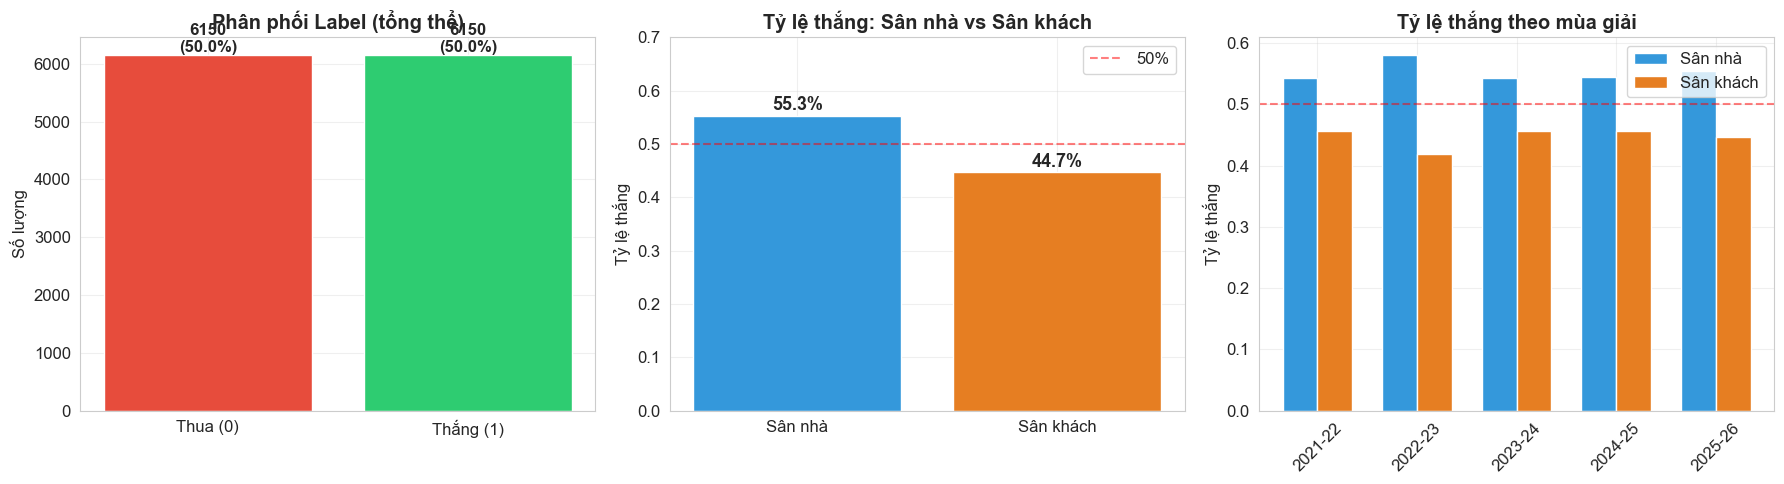


Lợi thế sân nhà: 55.3% vs 44.7% (chênh 10.6%)


In [5]:
# 2.1 — Phân phối Label + Home Court Advantage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Tổng thể
win_counts = df['WIN'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Thua (0)', 'Thắng (1)'], [win_counts[0], win_counts[1]], color=colors, edgecolor='white')
axes[0].set_title('Phân phối Label (tổng thể)', fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate([win_counts[0], win_counts[1]]):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# (b) Sân nhà vs Sân khách
home_win = df[df['IS_HOME']==1]['WIN'].mean()
away_win = df[df['IS_HOME']==0]['WIN'].mean()
bars = axes[1].bar(['Sân nhà', 'Sân khách'], [home_win, away_win], color=['#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('Tỷ lệ thắng: Sân nhà vs Sân khách', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ thắng')
axes[1].set_ylim(0, 0.7)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()
for bar, val in zip(bars, [home_win, away_win]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.1%}', ha='center', fontweight='bold', fontsize=13)

# (c) Theo mùa giải
home_by_season = df[df['IS_HOME']==1].groupby('SEASON')['WIN'].mean()
away_by_season = df[df['IS_HOME']==0].groupby('SEASON')['WIN'].mean()
x = range(len(home_by_season))
width = 0.35
axes[2].bar([i - width/2 for i in x], home_by_season.values, width, label='Sân nhà', color='#3498db')
axes[2].bar([i + width/2 for i in x], away_by_season.values, width, label='Sân khách', color='#e67e22')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(home_by_season.index, rotation=45)
axes[2].set_title('Tỷ lệ thắng theo mùa giải', fontweight='bold')
axes[2].set_ylabel('Tỷ lệ thắng')
axes[2].legend()
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nba_data/eda_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLợi thế sân nhà: {home_win:.1%} vs {away_win:.1%} (chênh {home_win - away_win:.1%})")

### Nhận xét Phần 2
- **Label cân bằng hoàn hảo** (50/50) → Accuracy là metric phù hợp, không cần xử lý imbalanced data
- **Home court advantage có thật**: đội nhà thắng ~55% vs đội khách ~45% → `IS_HOME` là feature hữu ích
- Lợi thế sân nhà **ổn định qua các mùa** → pattern này đáng tin cậy

## 4. Ma trận Tương quan (Correlation)

### Tại sao cần bước này?
Ma trận tương quan cho biết 2 điều quan trọng:

1. **Feature nào tương quan mạnh với WIN?** → Ưu tiên giữ lại cho mô hình
2. **Feature nào tương quan mạnh với nhau (multicollinearity)?** → Ví dụ: PTS và FGM tương quan rất cao (ghi điểm = ném rổ vào). Đưa cả 2 vào linear model sẽ gây bất ổn hệ số. Giải pháp: loại bớt 1 hoặc dùng tree-based model (ít bị ảnh hưởng)

Ngưỡng cần chú ý:
- **|r| > 0.7** giữa 2 features → multicollinearity cao
- **|r| > 0.3** với WIN → feature có tiềm năng

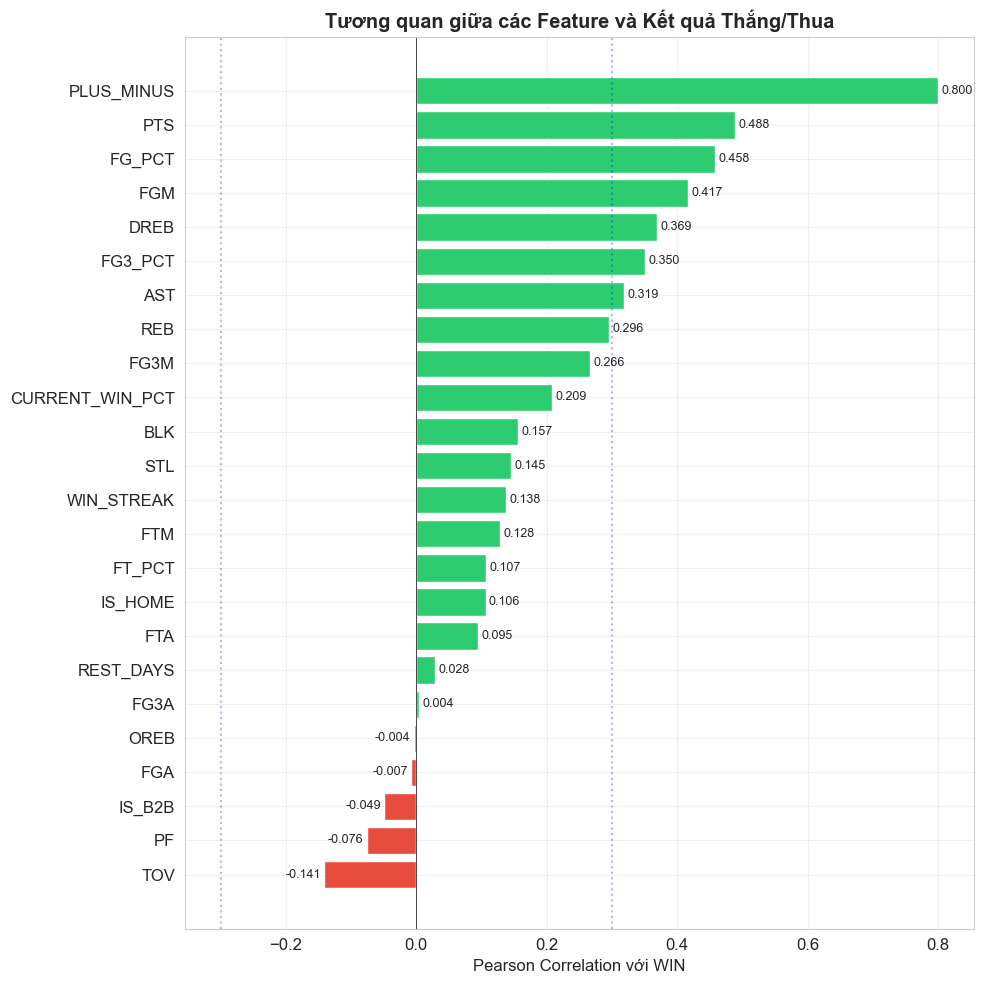

Top 5 feature tương quan DƯƠNG (giúp thắng):
  DREB                : +0.369
  FGM                 : +0.417
  FG_PCT              : +0.458
  PTS                 : +0.488
  PLUS_MINUS          : +0.800

Top 5 feature tương quan ÂM (dẫn đến thua):
  TOV                 : -0.141
  PF                  : -0.076
  IS_B2B              : -0.049
  FGA                 : -0.007
  OREB                : -0.004


In [7]:
# 4.1 — Tương quan với WIN
numeric_cols = ['PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
                'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 
                'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS',
                'IS_HOME', 'REST_DAYS', 'IS_B2B', 'CURRENT_WIN_PCT', 'WIN_STREAK']

corr_with_win = df[numeric_cols + ['WIN']].corr()['WIN'].drop('WIN').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_win.values]
bars = ax.barh(corr_with_win.index, corr_with_win.values, color=colors, edgecolor='white')
ax.set_xlabel('Pearson Correlation với WIN')
ax.set_title('Tương quan giữa các Feature và Kết quả Thắng/Thua', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axvline(x=0.3, color='blue', linestyle=':', alpha=0.3, label='|r|=0.3')
ax.axvline(x=-0.3, color='blue', linestyle=':', alpha=0.3)

for bar, val in zip(bars, corr_with_win.values):
    ax.text(val + 0.005 if val >= 0 else val - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('nba_data/eda_03_correlation_with_win.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 feature tương quan DƯƠNG (giúp thắng):")
for feat, val in corr_with_win.tail(5).items():
    print(f"  {feat:20s}: {val:+.3f}")
print("\nTop 5 feature tương quan ÂM (dẫn đến thua):")
for feat, val in corr_with_win.head(5).items():
    print(f"  {feat:20s}: {val:+.3f}")

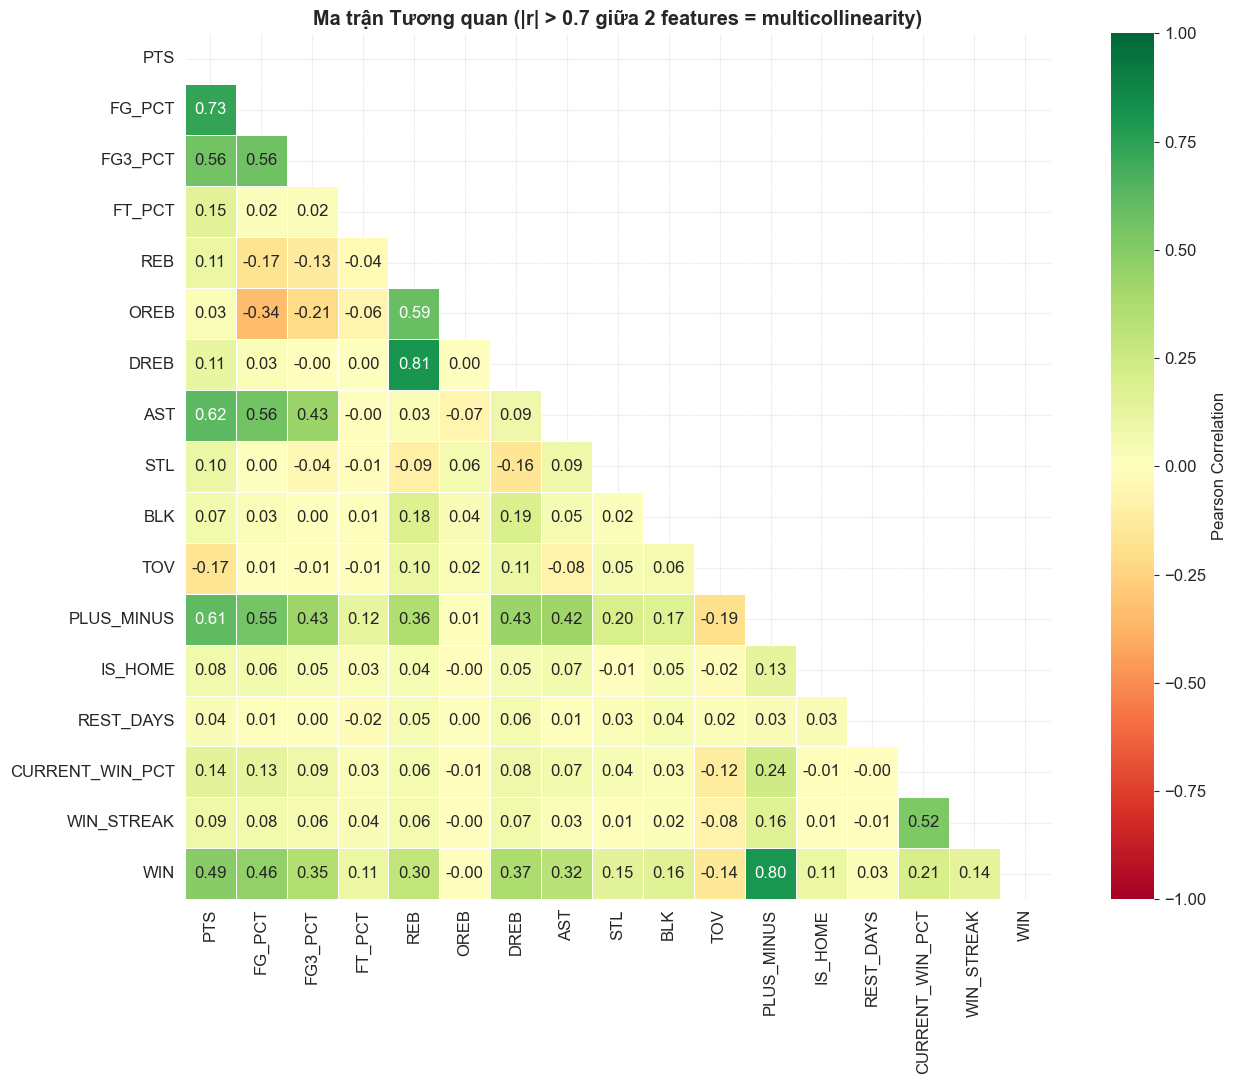

Các cặp feature có multicollinearity cao (|r| > 0.7):
  ⚠️ PTS             ↔ FG_PCT         : r = +0.732
  ⚠️ REB             ↔ DREB           : r = +0.808
  ⚠️ PLUS_MINUS      ↔ WIN            : r = +0.800


In [8]:
# 4.2 — Heatmap tương quan giữa các features (phát hiện multicollinearity)
key_features = ['PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'OREB', 'DREB',
                'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS',
                'IS_HOME', 'REST_DAYS', 'CURRENT_WIN_PCT', 'WIN_STREAK', 'WIN']

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Ma trận Tương quan (|r| > 0.7 giữa 2 features = multicollinearity)', fontweight='bold')

plt.tight_layout()
plt.savefig('nba_data/eda_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Cảnh báo multicollinearity
print("Các cặp feature có multicollinearity cao (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  ⚠️ {corr_matrix.columns[i]:15s} ↔ {corr_matrix.columns[j]:15s}: r = {r:+.3f}")

### Nhận xét Phần 4
- **PLUS_MINUS** tương quan cực mạnh với WIN → nhưng **KHÔNG ĐƯỢC DÙNG** vì đây là kết quả của trận, không phải input dự đoán (data leakage!)
    - **PLUS_MINUS** là chênh lệch điểm số cuối trận giữa đội đó và đối thủ. Ví dụ, ATL thắng DAL với tỷ số 113 - 87 -> **PLUS_MINUS** của ATL = +26, **PLUS_MINUS** của DAL = -26
    - Không được dùng feature này vì đây là data leakage: Nếu **PLUS_MINUS** > 0 -> chắc chắn WIN = 1. Nếu **PLUS_MINUS** < 0 -> Chắc chắn WIN = 0
- **FG_PCT, PTS, AST** là features tốt nhất (tương quan cao nhất sau PLUS_MINUS)
- **CURRENT_WIN_PCT, WIN_STREAK** (Nhóm 4) cũng có tương quan đáng kể → contextual features hữu ích
- **TOV, PF** tương quan âm → đội phạm lỗi nhiều và mất bóng nhiều dễ thua
- Cần cẩn thận với các cặp multicollinearity (PTS↔FGM, REB↔DREB,...) khi dùng linear models

## 5. Phân tích Contextual Features (Nhóm 4)

### Tại sao cần bước này?
Nhóm 4 là các feature ta **tự tạo** từ dữ liệu gốc. Cần kiểm chứng xem chúng có thực sự liên quan đến kết quả không:

- Nếu **có pattern rõ ràng** → feature tốt, giữ lại
- Nếu **không có pattern** → feature chỉ thêm noise, nên loại bỏ

Đây cũng là phần thú vị vì ta kiểm chứng được các "hiểu biết chung" về bóng rổ bằng dữ liệu:
- *"Đội back-to-back thường thua"* → Đúng hay sai?
- *"Momentum/hot hand có thật"* → Dữ liệu nói gì?

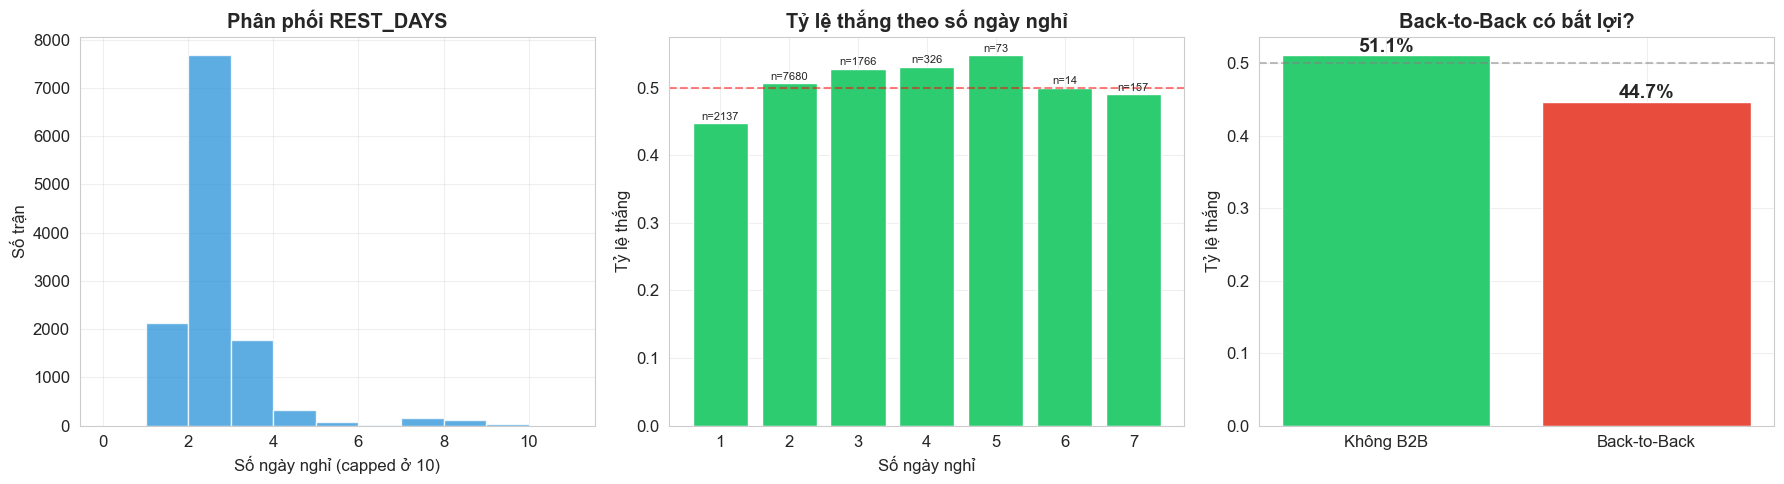

In [9]:
# 5.1 — REST_DAYS và Back-to-Back
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Phân phối REST_DAYS
rest_capped = df['REST_DAYS'].clip(upper=10)
axes[0].hist(rest_capped, bins=range(0, 12), color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Số ngày nghỉ (capped ở 10)')
axes[0].set_ylabel('Số trận')
axes[0].set_title('Phân phối REST_DAYS', fontweight='bold')

# (b) Tỷ lệ thắng theo REST_DAYS
rest_win = df[df['REST_DAYS'] <= 7].groupby('REST_DAYS')['WIN'].agg(['mean', 'count'])
bars = axes[1].bar(rest_win.index, rest_win['mean'], color='#2ecc71', edgecolor='white')
axes[1].set_xlabel('Số ngày nghỉ')
axes[1].set_ylabel('Tỷ lệ thắng')
axes[1].set_title('Tỷ lệ thắng theo số ngày nghỉ', fontweight='bold')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
for bar, (_, row) in zip(bars, rest_win.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'n={int(row["count"])}', ha='center', fontsize=8)

# (c) B2B vs Non-B2B
b2b_win = df.groupby('IS_B2B')['WIN'].mean()
bars = axes[2].bar(['Không B2B', 'Back-to-Back'], b2b_win.values, 
                    color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[2].set_ylabel('Tỷ lệ thắng')
axes[2].set_title('Back-to-Back có bất lợi?', fontweight='bold')
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, b2b_win.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('nba_data/eda_05_rest_days.png', dpi=150, bbox_inches='tight')
plt.show()

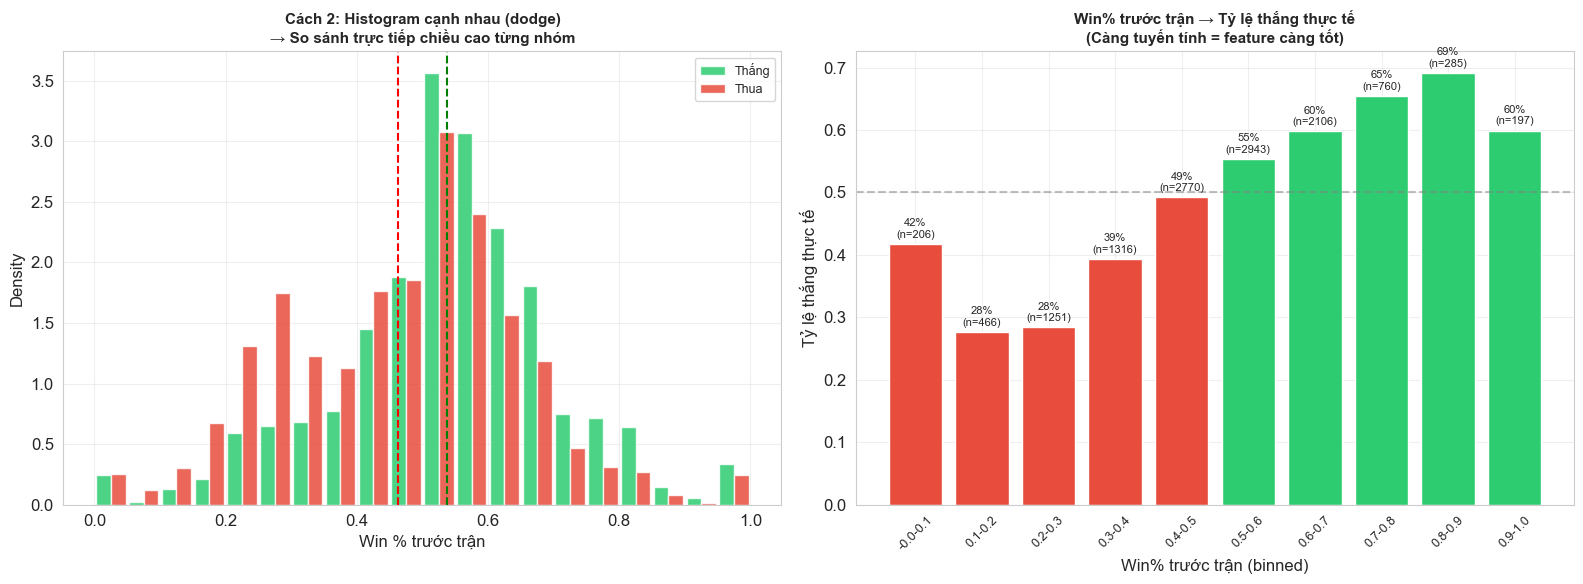

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

win_pct_w = df[df['WIN'] == 1]['CURRENT_WIN_PCT']
win_pct_l = df[df['WIN'] == 0]['CURRENT_WIN_PCT']


# ===== (b) Histogram KHÔNG chồng =====
bins = np.linspace(0, 1, 21)  # 20 bins
bin_centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0]) * 0.45

counts_w, _ = np.histogram(win_pct_w, bins=bins)
counts_l, _ = np.histogram(win_pct_l, bins=bins)
counts_w_norm = counts_w / (len(win_pct_w) * (bins[1] - bins[0]))
counts_l_norm = counts_l / (len(win_pct_l) * (bins[1] - bins[0]))

axes[0].bar(bin_centers - width/2, counts_w_norm, width=width, color='#2ecc71', edgecolor='white', label='Thắng', alpha=0.85)
axes[0].bar(bin_centers + width/2, counts_l_norm, width=width, color='#e74c3c', edgecolor='white', label='Thua', alpha=0.85)
axes[0].axvline(win_pct_w.mean(), color='green', linestyle='--', linewidth=1.5)
axes[0].axvline(win_pct_l.mean(), color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Win % trước trận')
axes[0].set_ylabel('Density')
axes[0].set_title('Cách 2: Histogram cạnh nhau (dodge)\n→ So sánh trực tiếp chiều cao từng nhóm', fontweight='bold', fontsize=11)
axes[0].legend(fontsize=9)

# ===== (c) Binned Win Rate =====
df['_BIN'] = pd.cut(df['CURRENT_WIN_PCT'], bins=10)
bin_win = df.groupby('_BIN', observed=True)['WIN'].agg(['mean', 'count'])
bin_win = bin_win[bin_win['count'] > 50]

colors = ['#e74c3c' if v < 0.5 else '#2ecc71' for v in bin_win['mean']]
bars = axes[1].bar(range(len(bin_win)), bin_win['mean'], color=colors, edgecolor='white')
axes[1].set_xticks(range(len(bin_win)))
axes[1].set_xticklabels([f'{iv.left:.1f}-{iv.right:.1f}' for iv in bin_win.index], rotation=45, fontsize=9)
axes[1].set_xlabel('Win% trước trận (binned)')
axes[1].set_ylabel('Tỷ lệ thắng thực tế')
axes[1].set_title('Win% trước trận → Tỷ lệ thắng thực tế\n(Càng tuyến tính = feature càng tốt)', fontweight='bold', fontsize=11)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, (_, row) in zip(bars, bin_win.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=8)

df.drop(columns=['_BIN'], inplace=True)

plt.tight_layout()
plt.savefig('nba_data/eda_06_win_pct.png', dpi=150, bbox_inches='tight')
plt.show()


**TRÁI: Histogram tách theo Thắng / Thua**
- Nhìn vào vùng Win% cao, màu xanh nhiều hơn màu đỏ. Ngược lại ở vùng Win% thấp (0.1 - 0.3), màu đỏ chiếm đa số. 
- Đội có Win% cao trước trận thì thường thắng, đội thấp thì thường thua. Hai phân phối tách biệt nhau -> `CURRENT_WIN_PCT` là feature phân biệt tốt

**PHẢI: Binned Win Rate**
- Chia `CURRENT_WIN_PCT` thành 10 khoảng rồi tính tỷ lệ thắng thực tế trong mỗi khoảng. 
- Đội có Win% trước trận 0.0 - 0.1 thì tỷ lệ thắng thực tế chỉ ~ 42%. Đội có Win% 0.8-0.9 thì tỷ lệ thắng thực tế ~70%

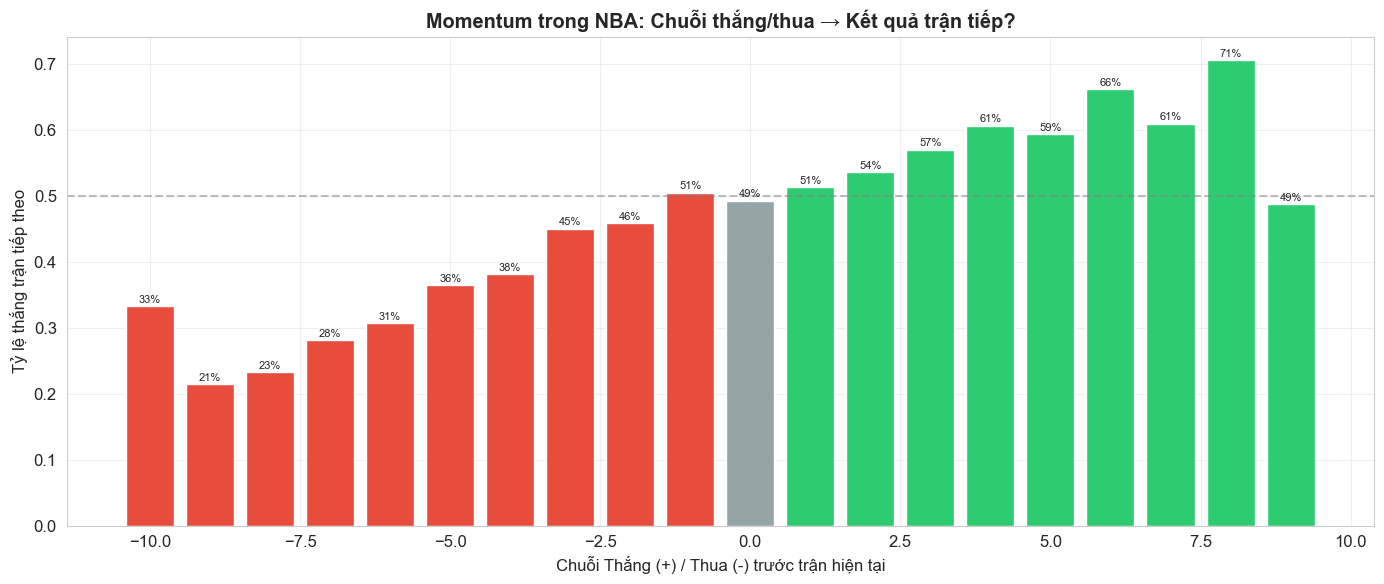

In [11]:
# 5.3 — WIN_STREAK: Momentum có thật không?
fig, ax = plt.subplots(figsize=(14, 6))

streak_data = df[(df['WIN_STREAK'] >= -10) & (df['WIN_STREAK'] <= 10)]
streak_win = streak_data.groupby('WIN_STREAK')['WIN'].agg(['mean', 'count'])
streak_win = streak_win[streak_win['count'] >= 30]

colors = ['#e74c3c' if idx < 0 else '#2ecc71' if idx > 0 else '#95a5a6' for idx in streak_win.index]
bars = ax.bar(streak_win.index, streak_win['mean'], color=colors, edgecolor='white')
ax.set_xlabel('Chuỗi Thắng (+) / Thua (-) trước trận hiện tại')
ax.set_ylabel('Tỷ lệ thắng trận tiếp theo')
ax.set_title('Momentum trong NBA: Chuỗi thắng/thua → Kết quả trận tiếp?', fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Ghi sample size
for bar, (idx, row) in zip(bars, streak_win.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["mean"]:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('nba_data/eda_07_momentum.png', dpi=150, bbox_inches='tight')
plt.show()

**Tại sao tới khúc 8,9 gì đó lại tụt**
- Sample size nhỏ: rất ít đội thắng 8 - 10 trận liên tiếp. Có thể ở streak +8 chỉ có vài chục trận trong toàn bộ dataset, trong khi streak +1 hoặc +2 có hàng nghìn trận. Khi sample size nhỏ, chỉ cần vài trận thua là tỷ lệ dao động rất mạnh. Ví dụ: nếu streak +8 chỉ có 30 trận mà 9 trận thua → tỷ lệ thắng chỉ còn 70%. Nhưng nếu có 1000 trận thì con số sẽ ổn định hơn nhiều.

### Nhận xét Phần 5
- **Back-to-back** ảnh hưởng tiêu cực → `IS_B2B` là feature hữu ích
- **CURRENT_WIN_PCT** có quan hệ gần tuyến tính với tỷ lệ thắng → feature rất mạnh (đội có win% cao thắng nhiều hơn thật)
- **WIN_STREAK** cho thấy momentum có thật: đội đang thắng liên tiếp có tỷ lệ thắng tiếp cao hơn → giữ feature này